In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [29]:
df = pd.read_csv(r'Stock Trend Project Dataset.csv')

**Data** **Cleaning** **and** **EDA**

In [30]:
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500.0,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000.0,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000.0,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500.0,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900.0,AAL


In [31]:
df.describe()

,open,high,low,close,volume
count,43772.000000,43772.000000,43772.000000,43771.000000,4.377100e+04
mean,80.935148,81.724488,80.125899,80.948735,5.420723e+06
std,56.902384,57.507784,56.239100,56.883607,1.298176e+07
min,1.620000,1.690000,1.610000,1.620000,7.802900e+04
25%,46.320000,46.760000,45.897500,46.340000,1.084540e+06
50%,62.870000,63.400000,62.342500,62.910000,2.022664e+06
75%,98.500000,99.450000,97.712500,98.580000,4.208745e+06
max,337.080000,340.340000,335.060000,339.500000,2.683365e+08


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43772 entries, 0 to 43771
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    43772 non-null  object 
 1   open    43772 non-null  float64
 2   high    43772 non-null  float64
 3   low     43772 non-null  float64
 4   close   43771 non-null  float64
 5   volume  43771 non-null  float64
 6   Name    43771 non-null  object 
dtypes: float64(5), object(2)
memory usage: 2.3+ MB


In [33]:
df.isnull().sum()

,0
date,0
open,0
high,0
low,0
close,1
volume,1
Name,1


In [34]:
df['open'].fillna(method='ffill', inplace=True)
df['high'].fillna(method='ffill', inplace=True)
df['low'].fillna(method='ffill', inplace=True)


df.isnull().sum()

,0
date,0
open,0
high,0
low,0
close,1
volume,1
Name,1


In [35]:
df['date'] = pd.to_datetime(df['date'])

In [36]:
df.dtypes

,0
date,datetime64[ns]
open,float64
high,float64
low,float64
close,float64
volume,float64
Name,object


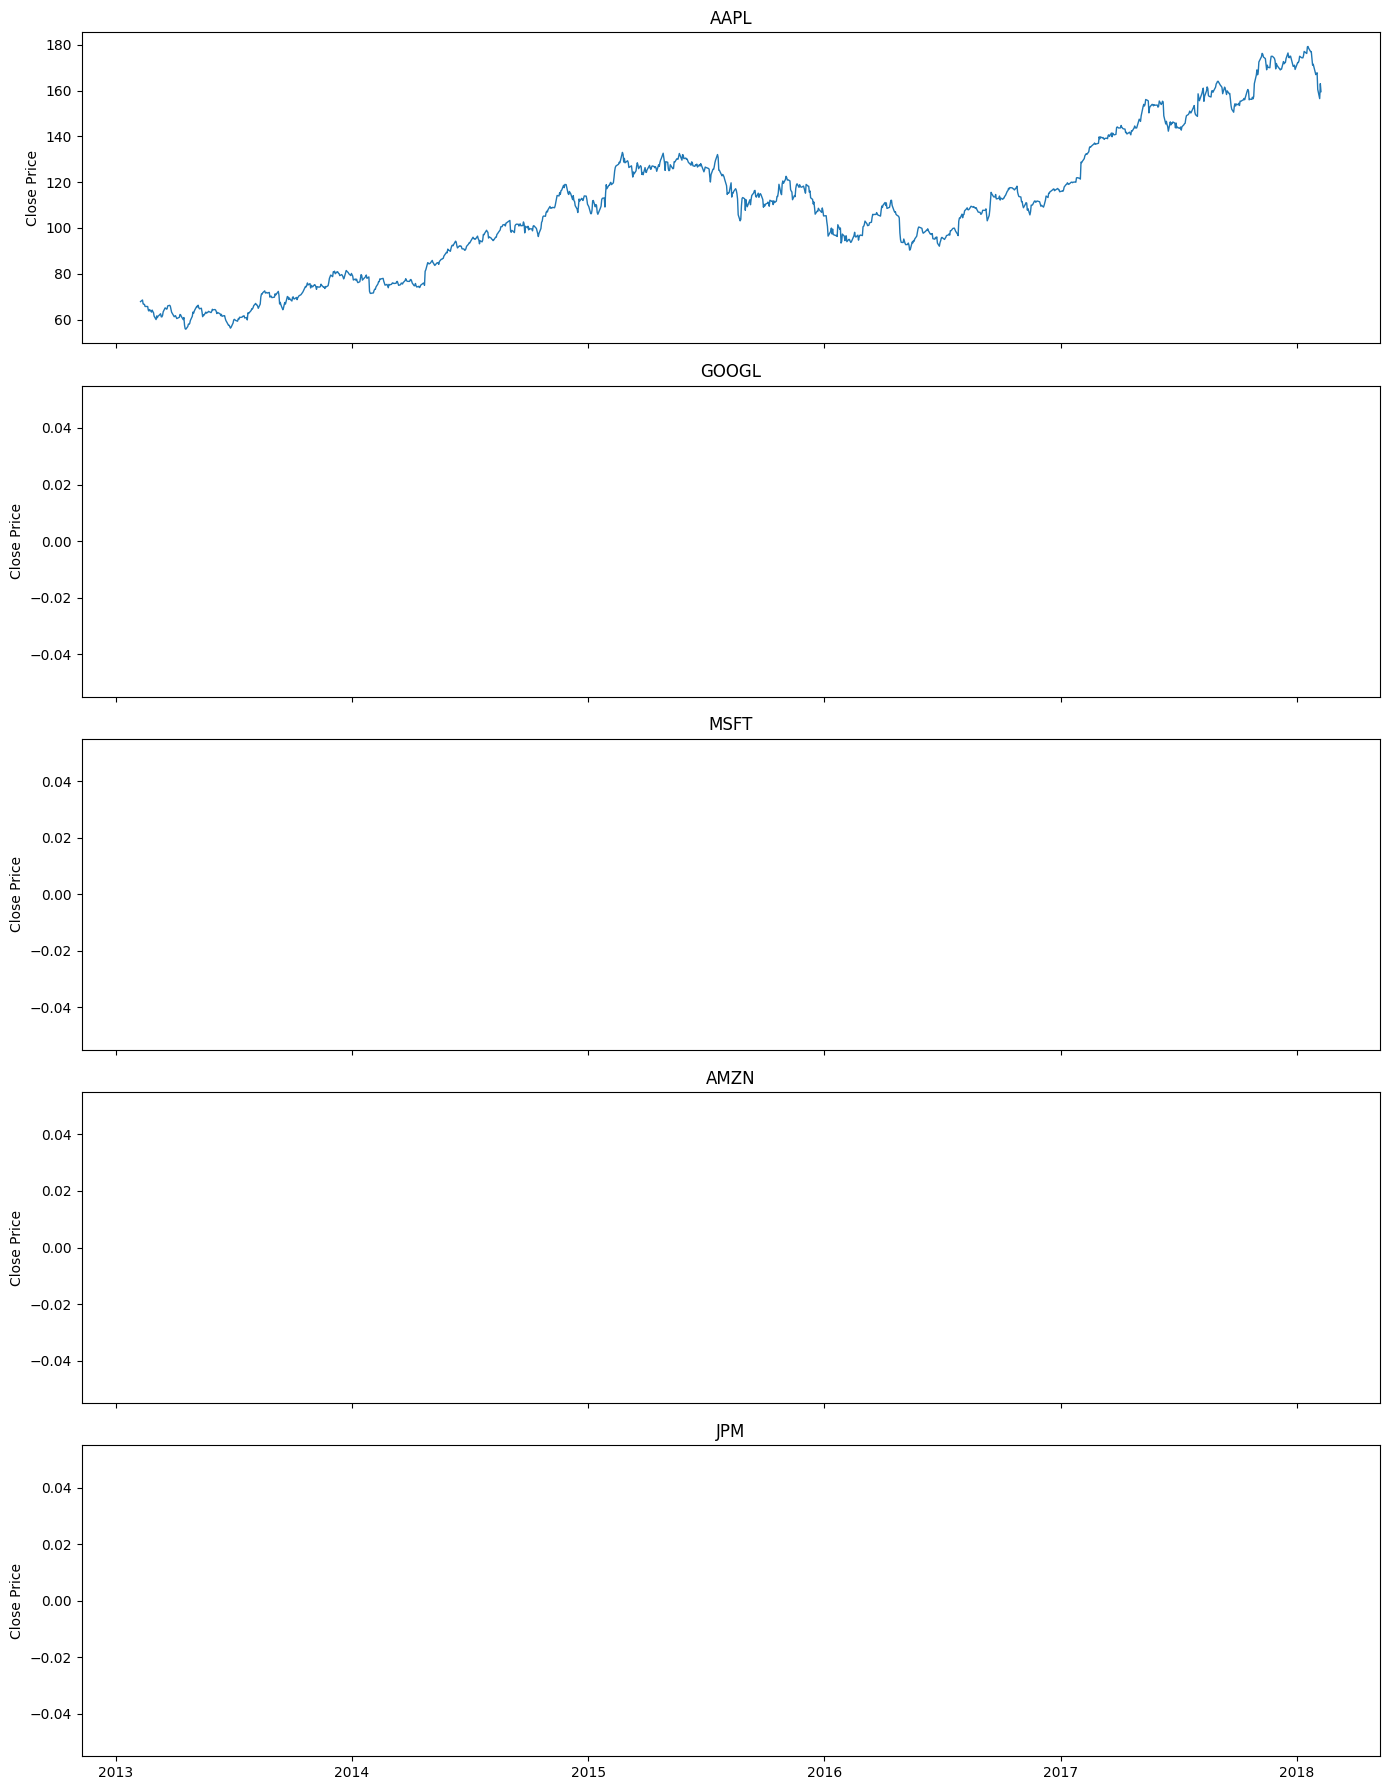

In [37]:
import matplotlib.pyplot as plt

samples = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'JPM']
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

for ax, name in zip(axes, samples):
    subset = df[df['Name'] == name].sort_values('date')
    ax.plot(subset['date'], subset['close'], linewidth=1)
    ax.set_title(name)
    ax.set_ylabel('Close Price')

plt.tight_layout()
plt.show()

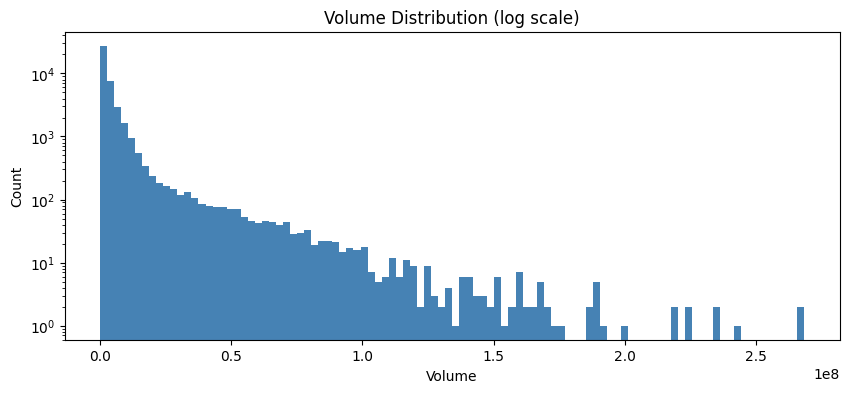

In [38]:
plt.figure(figsize=(10, 4))
plt.hist(df['volume'], bins=100, log=True, color='steelblue', edgecolor='none')
plt.title('Volume Distribution (log scale)')
plt.xlabel('Volume')
plt.ylabel('Count')
plt.show()

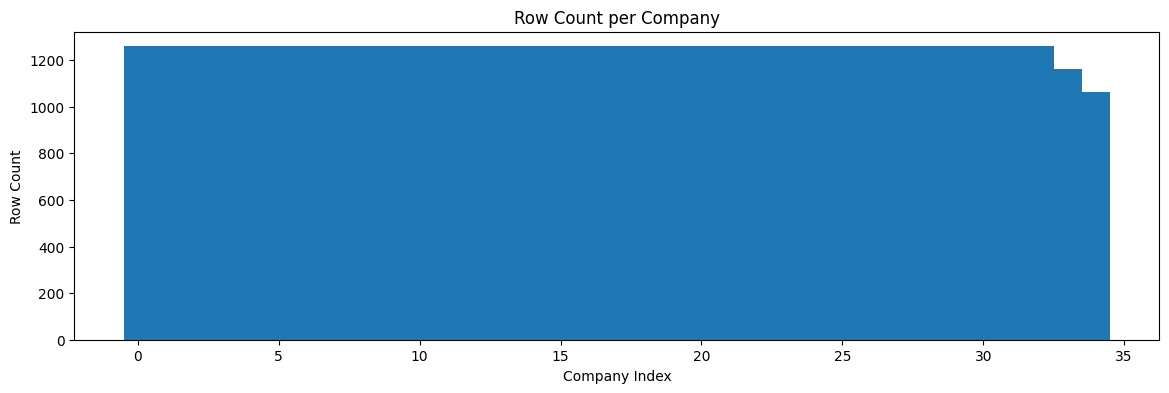

In [39]:
counts = df['Name'].value_counts()
plt.figure(figsize=(14, 4))
plt.bar(range(len(counts)), counts.values, width=1.0)
plt.title('Row Count per Company')
plt.xlabel('Company Index')
plt.ylabel('Row Count')
plt.show()

**Feature** **Engineering**

In [40]:
df = df.sort_values(['Name', 'date']).reset_index(drop=True)

In [41]:
df['momentum'] = df.groupby('Name')['close'].transform(lambda x: x / x.shift(5) - 1)

In [42]:
threshold = 0.02

df['target'] = df.groupby('Name')['close'].transform(
    lambda x: x.shift(-5) / x - 1
)

In [43]:
df['roc'] = df.groupby('Name')['close'].transform(lambda x: x.pct_change(10))

In [44]:
df = df[df['target'].abs() > threshold].copy()

In [45]:
df['volatility'] = df.groupby('Name')['close'].transform(lambda x: x.rolling(10).std() / x.rolling(20).std())

In [46]:
df['target'] = (df['target'] > 0).astype(int)

df = df.dropna().reset_index(drop=True)

print(df.shape)
print(df['target'].value_counts())

(19880, 11)
target
1    11445
0     8435
Name: count, dtype: int64


In [47]:
df['gap'] = (df['open'] - df.groupby('Name')['close'].transform(lambda x: x.shift(1))) / df.groupby('Name')['close'].transform(lambda x: x.shift(1))

In [48]:
df['MA7'] = df.groupby('Name')['close'].transform(lambda x: x.rolling(7).mean())
df['MA21'] = df.groupby('Name')['close'].transform(lambda x: x.rolling(21).mean())

In [49]:
df['vol_momentum'] = df.groupby('Name')['volume'].transform(lambda x: x / x.rolling(10).mean())

In [50]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = -delta.clip(upper=0).rolling(period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = df.groupby('Name')['close'].transform(compute_rsi)

In [51]:
df['EMA12'] = df.groupby('Name')['close'].transform(lambda x: x.ewm(span=12).mean())
df['EMA26'] = df.groupby('Name')['close'].transform(lambda x: x.ewm(span=26).mean())
df['MACD'] = df['EMA12'] - df['EMA26']

In [52]:
df['BB_mid'] = df.groupby('Name')['close'].transform(lambda x: x.rolling(21).mean())
df['BB_std'] = df.groupby('Name')['close'].transform(lambda x: x.rolling(21).std())
df['BB_upper'] = df['BB_mid'] + 2 * df['BB_std']
df['BB_lower'] = df['BB_mid'] - 2 * df['BB_std']

In [53]:
df['ticker_id'] = df['Name'].astype('category').cat.codes

In [54]:
df = df.dropna().reset_index(drop=True)

print(df.shape)
print(df['target'].describe())

(19180, 24)
count    19180.000000
mean         0.573358
std          0.494602
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: target, dtype: float64


**Data** **preprocessing**

In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
clip_val = df['target'].std() * 3
df['target'] = df['target'].clip(-clip_val, clip_val)

In [57]:
feature_cols = ['open', 'high', 'low', 'close', 'volume',
                'MA7', 'MA21', 'RSI', 'MACD',
                'BB_upper', 'BB_lower', 'ticker_id',
                'momentum', 'roc', 'volatility', 'gap', 'vol_momentum']

In [58]:
split_date = df['date'].quantile(0.8)
train_df = df[df['date'] <= split_date].copy()
test_df = df[df['date'] > split_date].copy()

scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [59]:
SEQ_LEN = 30

In [60]:
def create_sequences(data, feature_cols, target_col, seq_len=30):
    X, y = [], []
    for name, group in data.groupby('Name'):
        group = group.sort_values('date').reset_index(drop=True)
        features = group[feature_cols].values
        targets = group[target_col].values
        for i in range(seq_len, len(group)):
            X.append(features[i-seq_len:i])
            y.append(targets[i])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_df, feature_cols, 'target', SEQ_LEN)
X_test, y_test = create_sequences(test_df, feature_cols, 'target', SEQ_LEN)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (14303, 30, 17), X_test: (2777, 30, 17)


 **Model** **Building** **&** **Training**

In [61]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [62]:
from sklearn.utils import resample


train_up = train_df[train_df['target'] == 1]
train_down = train_df[train_df['target'] == 0]


train_up_sampled = resample(train_up, n_samples=len(train_down), random_state=42)


train_balanced = pd.concat([train_up_sampled, train_down]).sample(frac=1, random_state=42).reset_index(drop=True)

print(train_balanced['target'].value_counts())

target
1    6656
0    6656
Name: count, dtype: int64


In [63]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=512, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=512, shuffle=False)

In [64]:
class StockLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.3):
        super(StockLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.bn = nn.BatchNorm1d(64)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc1(out)
        out = self.relu(out)
        out = self.bn(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out.squeeze()

In [65]:
class StockGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.3):
        super(StockGRU, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.bn = nn.BatchNorm1d(64)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc1(out)
        out = self.relu(out)
        out = self.bn(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out.squeeze()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [68]:
final_gru_model = StockGRU(input_size=len(feature_cols), hidden_size=128, num_layers=2, dropout=0.3).to(device)
final_criterion = nn.BCEWithLogitsLoss()
final_optimizer = torch.optim.Adam(final_gru_model.parameters(), lr=0.001)
final_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(final_optimizer, mode='min', factor=0.5, patience=5)

EPOCHS = 10
best_final_acc = 0
best_final_f1 = -1
best_final_thresh = 0.5

print("Starting final GRU model training...")

for epoch in range(EPOCHS):
    final_gru_model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        final_optimizer.zero_grad()
        preds = final_gru_model(X_batch)
        loss = final_criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_gru_model.parameters(), max_norm=1.0)
        final_optimizer.step()
        train_loss += loss.item()

    final_gru_model.eval()
    all_preds_test, all_targets_test = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = final_gru_model(X_batch)
            all_preds_test.append(preds.cpu())
            all_targets_test.append(y_batch.cpu())

    all_preds_test = torch.cat(all_preds_test)
    all_targets_test = torch.cat(all_targets_test)
    probs_test = torch.sigmoid(all_preds_test).numpy()
    true_np_test = all_targets_test.numpy()


    acc = ((probs_test > 0.5) == true_np_test).mean() * 100
    current_lr = final_optimizer.param_groups[0]['lr']

    epoch_best_f1 = -1
    epoch_best_thresh = 0.5
    for t in np.arange(0.3, 0.7, 0.01):
        f1 = f1_score(true_np_test, (probs_test > t).astype(int), average='macro')
        if f1 > epoch_best_f1:
            epoch_best_f1 = f1
            epoch_best_thresh = t

    if epoch_best_f1 > best_final_f1:
        best_final_f1 = epoch_best_f1
        best_final_thresh = epoch_best_thresh
        torch.save(final_gru_model.state_dict(), 'final_gru_model.pt')

    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"Train Loss: {train_loss/len(train_loader):.6f} | "
          f"Test Acc: {acc:.2f}% | "
          f"Test Macro F1: {epoch_best_f1:.4f} (Thresh: {epoch_best_thresh:.2f}) | "
          f"Best Macro F1: {best_final_f1:.4f} (Thresh: {best_final_thresh:.2f}) | "
          f"LR: {current_lr:.6f}")

    final_scheduler.step(train_loss / len(train_loader))

print(f"\nFinal GRU model training complete!")
print(f"Best Macro F1 Score achieved: {best_final_f1:.4f} with threshold: {best_final_thresh:.2f}")

import joblib


joblib.dump(best_final_thresh, 'final_tuned_threshold.pkl')
print(f"Best tuned threshold for final model saved to 'final_tuned_threshold.pkl'")

Starting final GRU model training...
Epoch 001/10 | Train Loss: 0.706391 | Test Acc: 53.44% | Test Macro F1: 0.5185 (Thresh: 0.50) | Best Macro F1: 0.5185 (Thresh: 0.50) | LR: 0.001000
Epoch 002/10 | Train Loss: 0.689303 | Test Acc: 53.94% | Test Macro F1: 0.5056 (Thresh: 0.52) | Best Macro F1: 0.5185 (Thresh: 0.50) | LR: 0.001000
Epoch 003/10 | Train Loss: 0.685722 | Test Acc: 55.10% | Test Macro F1: 0.5169 (Thresh: 0.56) | Best Macro F1: 0.5185 (Thresh: 0.50) | LR: 0.001000
Epoch 004/10 | Train Loss: 0.682235 | Test Acc: 54.45% | Test Macro F1: 0.4970 (Thresh: 0.54) | Best Macro F1: 0.5185 (Thresh: 0.50) | LR: 0.001000
Epoch 005/10 | Train Loss: 0.678932 | Test Acc: 53.01% | Test Macro F1: 0.4817 (Thresh: 0.51) | Best Macro F1: 0.5185 (Thresh: 0.50) | LR: 0.001000
Epoch 006/10 | Train Loss: 0.674759 | Test Acc: 52.07% | Test Macro F1: 0.4889 (Thresh: 0.49) | Best Macro F1: 0.5185 (Thresh: 0.50) | LR: 0.001000
Epoch 007/10 | Train Loss: 0.674896 | Test Acc: 53.80% | Test Macro F1: 0.4

Classification Report for Final GRU Model (Threshold: 0.50):

              precision    recall  f1-score   support

        Down       0.44      0.42      0.43      1158
          Up       0.60      0.61      0.61      1619

    accuracy                           0.53      2777
   macro avg       0.52      0.52      0.52      2777
weighted avg       0.53      0.53      0.53      2777

ROC-AUC: 0.5167


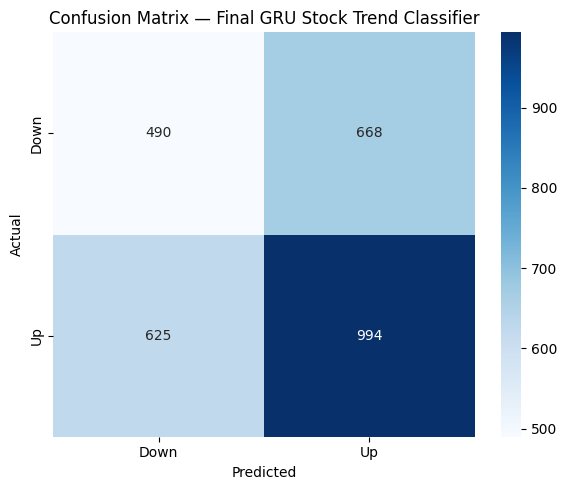

In [69]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns


final_gru_model.load_state_dict(torch.load('final_gru_model.pt'))
final_gru_model.eval()

all_preds_final, all_targets_final = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds_final = final_gru_model(X_batch)
        all_preds_final.append(preds_final.cpu())
        all_targets_final.append(y_batch.cpu())

all_preds_final = torch.cat(all_preds_final)
all_targets_final = torch.cat(all_targets_final)


final_probs = torch.sigmoid(all_preds_final).numpy()
final_pred_labels = (final_probs > best_final_thresh).astype(int)
final_true_labels = all_targets_final.int().numpy()

print(f"Classification Report for Final GRU Model (Threshold: {best_final_thresh:.2f}):\n")
print(classification_report(final_true_labels, final_pred_labels, target_names=['Down', 'Up']))
print(f"ROC-AUC: {roc_auc_score(final_true_labels, final_probs):.4f}")

cm_final = confusion_matrix(final_true_labels, final_pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'],
            yticklabels=['Down', 'Up'])
plt.title('Confusion Matrix — Final GRU Stock Trend Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [74]:
sample_size = 5
if len(test_df) < SEQ_LEN + sample_size:
    print("Not enough data in test_df to create a meaningful sample for inference.")

    exit()


valid_tickers_in_test = test_df.groupby('Name').filter(lambda x: len(x) >= SEQ_LEN)['Name'].unique()

if len(valid_tickers_in_test) < sample_size:
    print(f"Not enough tickers in test_df with sufficient length for sequences. Found {len(valid_tickers_in_test)}.")
    sample_tickers = valid_tickers_in_test
else:
    sample_tickers = np.random.choice(valid_tickers_in_test, sample_size, replace=False)

sample_X, sample_y, sample_dates = [], [], []

for ticker_name in sample_tickers:
    ticker_subset = test_df[test_df['Name'] == ticker_name].sort_values('date').reset_index(drop=True)


    if len(ticker_subset) >= SEQ_LEN:

        X_sample_seq = ticker_subset[feature_cols].values[-SEQ_LEN:]
        y_sample_true = ticker_subset['target'].values[-1]
        date_sample = ticker_subset['date'].values[-1]

        sample_X.append(X_sample_seq)
        sample_y.append(y_sample_true)
        sample_dates.append(date_sample)

if not sample_X:
    print("Could not form any valid sequences from the sampled tickers.")
else:
    sample_X_tensor = torch.tensor(np.array(sample_X), dtype=torch.float32).to(device)


    final_gru_model.eval()
    with torch.no_grad():
        raw_predictions = final_gru_model(sample_X_tensor)
        probabilities = torch.sigmoid(raw_predictions).cpu().numpy()


    import joblib
    best_final_thresh = joblib.load('final_tuned_threshold.pkl')

    predicted_labels = (probabilities > best_final_thresh).astype(int)

    print(f"\n--- Model Predictions (using threshold: {best_final_thresh:.2f}) ---")
    for i in range(len(sample_X)):
        print(f"Ticker: {sample_tickers[i]}, Date: {pd.to_datetime(sample_dates[i]).strftime('%Y-%m-%d')}")
        print(f"  Predicted Probability of 'Up': {probabilities[i]:.4f}")
        print(f"  Predicted Trend: {'Up' if predicted_labels[i] == 1 else 'Down'}")
        print(f"  Actual Trend:    {'Up' if sample_y[i] == 1 else 'Down'}")
        print("--------------------------------------------------")


--- Model Predictions (using threshold: 0.50) ---
Ticker: AME, Date: 2018-01-31
  Predicted Probability of 'Up': 0.4671
  Predicted Trend: Down
  Actual Trend:    Down
--------------------------------------------------
Ticker: AEE, Date: 2018-01-31
  Predicted Probability of 'Up': 0.5438
  Predicted Trend: Up
  Actual Trend:    Down
--------------------------------------------------
Ticker: ABT, Date: 2018-01-31
  Predicted Probability of 'Up': 0.4969
  Predicted Trend: Down
  Actual Trend:    Down
--------------------------------------------------
Ticker: AMGN, Date: 2018-01-31
  Predicted Probability of 'Up': 0.4433
  Predicted Trend: Down
  Actual Trend:    Down
--------------------------------------------------
Ticker: AGN, Date: 2018-01-31
  Predicted Probability of 'Up': 0.4652
  Predicted Trend: Down
  Actual Trend:    Down
--------------------------------------------------
